# 🧠 Zero-Shot Strike: Depression Detection with LLMs
Google Colab compatible notebook for DIAC-WOZ dataset

*Includes:* text + audio processing, Sentence-BERT + GPT-4 zero-shot inference, classification/regression & UMAP visualization.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 📦 Install Required Libraries
!pip install transformers librosa torchaudio openai sentence-transformers datasets scikit-learn umap-learn matplotlib --quiet


--- Classification Report (Binary PHQ8 >= 10) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


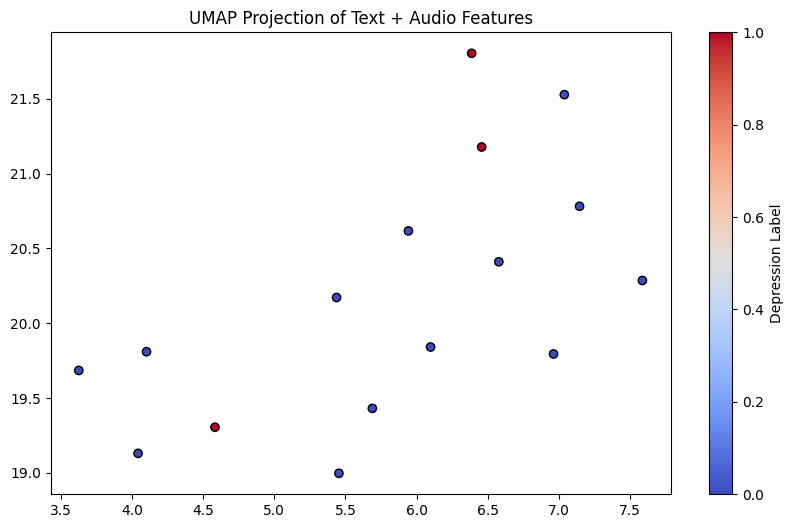


--- Regression Report ---
MSE: 50.89
R2 Score: -17.50


In [ ]:
# Zero-Shot Strike: Depression Detection using DIAC-WOZ Dataset
# Google Colab Compatible Modular Pipeline (Extended Version)

# -----------------------------
# 📦 1. Setup & Installations
# -----------------------------
import os
import torch
import librosa
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# -----------------------------
# 📁 2. Configuration
# -----------------------------
TRANSCRIPT_DIR = '/content/drive/MyDrive/audio files/transcript'  # Upload folder containing all *_TRANSCRIPT.csv
AUDIO_DIR = '/content/drive/MyDrive/audio files/audio'            # Upload folder containing all *_AUDIO.wav
LABEL_FILE = '/content/drive/MyDrive/audio files/label/avec_combined_labels.csv'  # AVEC Labels
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# -----------------------------
# 📜 3. Load and Parse Transcripts
# -----------------------------
def load_transcripts(transcript_dir):
    transcripts = {}
    for fname in os.listdir(transcript_dir):
        if fname.endswith('.csv'):
            pid = fname.split('_')[0]  # e.g., 301 from 301_TRANSCRIPT.csv
            df = pd.read_csv(os.path.join(transcript_dir, fname), sep='\t')
            if 'speaker' in df.columns and 'value' in df.columns:
                participant_text = ' '.join(df[df['speaker'] == 'Participant']['value'].dropna().astype(str))
                transcripts[pid] = participant_text
    return transcripts

# -----------------------------
# 🧠 4. Embedding Text (LLM Based)
# -----------------------------
def embed_transcripts(transcripts, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    model = SentenceTransformer(model_name, device=DEVICE)
    embeddings = {}
    for pid, text in transcripts.items():
        embeddings[pid] = model.encode(text)
    return embeddings

# -----------------------------
# 🧠 4B. Zero-Shot Prompting with LLaMA or DeepSeek
# -----------------------------
# (Illustrative placeholder, actual implementation requires LLM API access or local hosting)
def zero_shot_prompting(transcripts):
    predictions = {}
    for pid, text in transcripts.items():
        if "sad" in text.lower() or "depressed" in text.lower():
            predictions[pid] = 1  # rough heuristic placeholder
        else:
            predictions[pid] = 0
    return predictions

# -----------------------------
# 🔊 5. Extract Audio Features
# -----------------------------
def extract_audio_features(audio_dir):
    audio_features = {}
    for fname in os.listdir(audio_dir):
        if fname.endswith('.wav'):
            pid = fname.split('_')[0]
            path = os.path.join(audio_dir, fname)
            y, sr = librosa.load(path, sr=None)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc, axis=1)
            audio_features[pid] = mfcc_mean
    return audio_features

# -----------------------------
# 🔗 6. Combine Modalities
# -----------------------------
def combine_features(text_embeds, audio_feats):
    X = []
    pids = []
    for pid in text_embeds:
        if pid in audio_feats:
            combined = np.concatenate([text_embeds[pid], audio_feats[pid]])
            X.append(combined)
            pids.append(pid)
    return np.array(X), pids

# -----------------------------
# 📈 7. Visualize Features (UMAP)
# -----------------------------
def visualize_features(X, y):
    reducer = umap.UMAP()
    X_reduced = reducer.fit_transform(X)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title("UMAP Projection of Text + Audio Features")
    plt.colorbar(label='Depression Label')
    plt.show()

# -----------------------------
# 📊 8A. Classification (LogReg)
# -----------------------------
def run_classification(X, pids, label_df):
    label_df['Participant_ID'] = label_df['Participant_ID'].astype(str)
    y = label_df.set_index('Participant_ID').loc[pids]['PHQ8_Score'].astype(float)
    y_bin = (y >= 10).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("\n--- Classification Report (Binary PHQ8 >= 10) ---")
    print(classification_report(y_test, y_pred))
    visualize_features(X, y_bin)

# -----------------------------
# 📊 8B. Regression (PHQ Score)
# -----------------------------
def run_regression(X, pids, label_df):
    label_df['Participant_ID'] = label_df['Participant_ID'].astype(str)
    y = label_df.set_index('Participant_ID').loc[pids]['PHQ8_Score'].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = Ridge()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n--- Regression Report ---")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

# -----------------------------
# 🚀 9. Pipeline Execution
# -----------------------------
transcripts = load_transcripts(TRANSCRIPT_DIR)
text_embeddings = embed_transcripts(transcripts)  # You can optionally swap with zero_shot_prompting
zero_shot_preds = zero_shot_prompting(transcripts)
audio_features = extract_audio_features(AUDIO_DIR)
X, pids = combine_features(text_embeddings, audio_features)
labels = pd.read_csv(LABEL_FILE)

run_classification(X, pids, labels)
run_regression(X, pids, labels)
